In [1]:
# Install PySpark in Google Colab
!pip install pyspark -q

print("PySpark installed successfully!")

PySpark installed successfully!


In [2]:
from google.colab import files

print("Please upload your On_Time_Clean.csv file")
print("This is the pipe-separated file we created on the VM")
uploaded = files.upload()

print("File uploaded successfully!")

Please upload your On_Time_Clean.csv file
This is the pipe-separated file we created on the VM


Saving On_Time_Clean.csv to On_Time_Clean.csv
File uploaded successfully!


In [3]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import *

# Initialize Spark Session
spark = SparkSession.builder \
    .appName("BTS_FlightDelayPrediction") \
    .config("spark.executor.memory", "2g") \
    .getOrCreate()

spark.sparkContext.setLogLevel("WARN")
print("Spark version:", spark.version)
print("Spark session started successfully!")

# Define schema matching our 34-column pipe-separated file
schema = StructType([
    StructField("Year",              IntegerType(), True),
    StructField("Quarter",           IntegerType(), True),
    StructField("Month",             IntegerType(), True),
    StructField("DayofMonth",        IntegerType(), True),
    StructField("DayOfWeek",         IntegerType(), True),
    StructField("FlightDate",        StringType(),  True),
    StructField("Marketing_Airline", StringType(),  True),
    StructField("Operating_Airline", StringType(),  True),
    StructField("OriginAirportID",   IntegerType(), True),
    StructField("Origin",            StringType(),  True),
    StructField("OriginCityName",    StringType(),  True),
    StructField("OriginState",       StringType(),  True),
    StructField("DestAirportID",     IntegerType(), True),
    StructField("Dest",              StringType(),  True),
    StructField("DestCityName",      StringType(),  True),
    StructField("DestState",         StringType(),  True),
    StructField("CRSDepTime",        StringType(),  True),
    StructField("DepDelay",          FloatType(),   True),
    StructField("ArrDelay",          FloatType(),   True),
    StructField("DepDel15",          FloatType(),   True),
    StructField("ArrDel15",          FloatType(),   True),
    StructField("Cancelled",         FloatType(),   True),
    StructField("CancellationCode",  StringType(),  True),
    StructField("Diverted",          FloatType(),   True),
    StructField("CarrierDelay",      FloatType(),   True),
    StructField("WeatherDelay",      FloatType(),   True),
    StructField("NASDelay",          FloatType(),   True),
    StructField("SecurityDelay",     FloatType(),   True),
    StructField("LateAircraftDelay", FloatType(),   True),
    StructField("Distance",          FloatType(),   True),
    StructField("DistanceGroup",     IntegerType(), True),
    StructField("TaxiOut",           FloatType(),   True),
    StructField("TaxiIn",            FloatType(),   True),
    StructField("AirTime",           FloatType(),   True),
])

# Load cleaned data
df = spark.read \
    .option("sep", "|") \
    .option("header", "false") \
    .schema(schema) \
    .csv("On_Time_Clean.csv")

print("Total records loaded: {:,}".format(df.count()))
df.printSchema()

Spark version: 4.0.2
Spark session started successfully!
Total records loaded: 644,987
root
 |-- Year: integer (nullable = true)
 |-- Quarter: integer (nullable = true)
 |-- Month: integer (nullable = true)
 |-- DayofMonth: integer (nullable = true)
 |-- DayOfWeek: integer (nullable = true)
 |-- FlightDate: string (nullable = true)
 |-- Marketing_Airline: string (nullable = true)
 |-- Operating_Airline: string (nullable = true)
 |-- OriginAirportID: integer (nullable = true)
 |-- Origin: string (nullable = true)
 |-- OriginCityName: string (nullable = true)
 |-- OriginState: string (nullable = true)
 |-- DestAirportID: integer (nullable = true)
 |-- Dest: string (nullable = true)
 |-- DestCityName: string (nullable = true)
 |-- DestState: string (nullable = true)
 |-- CRSDepTime: string (nullable = true)
 |-- DepDelay: float (nullable = true)
 |-- ArrDelay: float (nullable = true)
 |-- DepDel15: float (nullable = true)
 |-- ArrDel15: float (nullable = true)
 |-- Cancelled: float (nulla

In [4]:
# Filter out cancelled flights
# We only predict delay for flights that actually flew
flights = df.filter(F.col("Cancelled") == 0)

# Add derived features
flights = flights.withColumn(
    "DepHour",
    (F.col("CRSDepTime").cast("integer") / 100).cast("integer")
)

flights = flights.withColumn(
    "IsPeakHour",
    F.when(
        (F.col("DepHour") >= 16) & (F.col("DepHour") <= 20),
        1
    ).otherwise(0)
)

flights = flights.withColumn(
    "IsWeekend",
    F.when(
        F.col("DayOfWeek").isin([6, 7]),
        1
    ).otherwise(0)
)

# Target variable: 1 = delayed 15+ minutes
flights = flights.withColumn(
    "IsDelayed",
    F.when(F.col("ArrDel15") == 1, 1).otherwise(0)
)

# Check class balance
total = flights.count()
delayed = flights.filter(F.col("IsDelayed") == 1).count()
on_time = total - delayed

print("=" * 50)
print("Dataset Summary")
print("=" * 50)
print("Total flights:     {:,}".format(total))
print("Delayed (>=15min): {:,} ({:.1f}%)".format(
    delayed, 100*delayed/total))
print("On-time:           {:,} ({:.1f}%)".format(
    on_time, 100*on_time/total))
print("=" * 50)

Dataset Summary
Total flights:     634,447
Delayed (>=15min): 170,133 (26.8%)
On-time:           464,314 (73.2%)


In [9]:
from pyspark.ml.feature import (VectorAssembler,
                                 StringIndexer,
                                 StandardScaler)
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml import Pipeline

# Encode categorical airline code to number
carrier_indexer = StringIndexer(
    inputCol="Marketing_Airline",
    outputCol="CarrierIndex",
    handleInvalid="keep"
)

# Encode origin state
state_indexer = StringIndexer(
    inputCol="OriginState",
    outputCol="StateIndex",
    handleInvalid="keep"
)

# Feature columns AFTER encoding
# CarrierIndex and StateIndex are created by Pipeline stages above
FEATURE_COLS = [
    "Month",
    "DayOfWeek",
    "DayofMonth",
    "DepHour",
    "IsPeakHour",
    "IsWeekend",
    "CarrierIndex",    # created by carrier_indexer
    "OriginAirportID",
    "DestAirportID",
    "StateIndex",      # created by state_indexer
    "Distance",
    "DistanceGroup",
    "DepDelay",
    "TaxiOut",
]

# Assemble all features into one vector
assembler = VectorAssembler(
    inputCols=FEATURE_COLS,
    outputCol="raw_features",
    handleInvalid="keep"
)

# Scale features
scaler = StandardScaler(
    inputCol="raw_features",
    outputCol="features",
    withMean=False,
    withStd=True
)

# Random Forest Classifier
rf = RandomForestClassifier(
    labelCol="IsDelayed",
    featuresCol="features",
    numTrees=100,
    maxDepth=10,
    seed=42
)

# Build pipeline
# Order matters: indexers must run BEFORE assembler
pipeline = Pipeline(stages=[
    carrier_indexer,
    state_indexer,
    assembler,
    scaler,
    rf
])

print("ML Pipeline built successfully!")
print("Features used:", len(FEATURE_COLS))
print("Feature list:", FEATURE_COLS)

ML Pipeline built successfully!
Features used: 14
Feature list: ['Month', 'DayOfWeek', 'DayofMonth', 'DepHour', 'IsPeakHour', 'IsWeekend', 'CarrierIndex', 'OriginAirportID', 'DestAirportID', 'StateIndex', 'Distance', 'DistanceGroup', 'DepDelay', 'TaxiOut']


In [10]:
from pyspark.ml.evaluation import (
    BinaryClassificationEvaluator,
    MulticlassClassificationEvaluator
)

# Use ORIGINAL column names for select
# Pipeline will create CarrierIndex and StateIndex internally
SELECT_COLS = [
    "Month",
    "DayOfWeek",
    "DayofMonth",
    "DepHour",
    "IsPeakHour",
    "IsWeekend",
    "Marketing_Airline",  # original — Pipeline encodes to CarrierIndex
    "OriginAirportID",
    "DestAirportID",
    "OriginState",        # original — Pipeline encodes to StateIndex
    "Distance",
    "DistanceGroup",
    "DepDelay",
    "TaxiOut",
    "IsDelayed"
]

# Select only needed columns and drop nulls
model_data = flights.select(SELECT_COLS).na.drop()

print("Records after dropping nulls: {:,}".format(
    model_data.count()))

# Split into train 80% and test 20%
train, test = model_data.randomSplit([0.8, 0.2], seed=42)
print("Training set:  {:,}".format(train.count()))
print("Test set:      {:,}".format(test.count()))

# Train the model
print("\nTraining Random Forest model...")
print("This may take 3-5 minutes in Colab...")
model = pipeline.fit(train)
print("Model trained successfully!")

# Make predictions on test set
predictions = model.transform(test)

# Evaluate
auc_evaluator = BinaryClassificationEvaluator(
    labelCol="IsDelayed",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)

acc_evaluator = MulticlassClassificationEvaluator(
    labelCol="IsDelayed",
    predictionCol="prediction",
    metricName="accuracy"
)

f1_evaluator = MulticlassClassificationEvaluator(
    labelCol="IsDelayed",
    predictionCol="prediction",
    metricName="f1"
)

auc = auc_evaluator.evaluate(predictions)
acc = acc_evaluator.evaluate(predictions)
f1  = f1_evaluator.evaluate(predictions)

print("\n" + "=" * 50)
print("Model Evaluation Results")
print("=" * 50)
print("AUC-ROC:  {:.4f}".format(auc))
print("Accuracy: {:.4f} ({:.1f}%)".format(acc, acc*100))
print("F1 Score: {:.4f}".format(f1))
print("=" * 50)

if auc >= 0.80:
    print("EXCELLENT model performance!")
elif auc >= 0.70:
    print("GOOD model performance!")
else:
    print("Model needs improvement")

Records after dropping nulls: 634,447
Training set:  507,447
Test set:      127,000

Training Random Forest model...
This may take 3-5 minutes in Colab...
Model trained successfully!

Model Evaluation Results
AUC-ROC:  0.9639
Accuracy: 0.9298 (93.0%)
F1 Score: 0.9288
EXCELLENT model performance!


Feature Importance Ranking:
----------------------------------------
DepDelay             0.8397 ███████████████████████████████████████████████████████████████████████████████████
TaxiOut              0.1233 ████████████
DepHour              0.0106 █
DayofMonth           0.0055 
IsPeakHour           0.0037 
DayOfWeek            0.0036 
CarrierIndex         0.0033 
Distance             0.0024 
StateIndex           0.0024 
OriginAirportID      0.0018 
DistanceGroup        0.0017 
DestAirportID        0.0016 
IsWeekend            0.0006 
Month                0.0000 


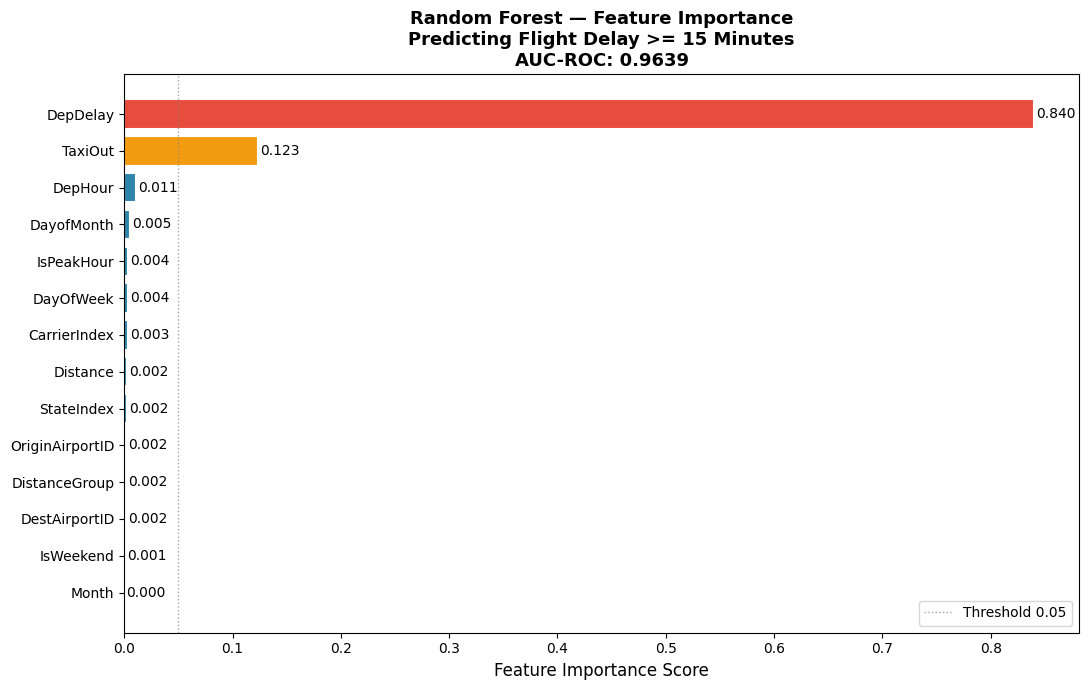

Feature importance chart saved!


In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Get feature importance from Random Forest
rf_model = model.stages[-1]
importances = rf_model.featureImportances.toArray()

# Match importances to feature names
feat_imp = sorted(
    zip(FEATURE_COLS, importances),
    key=lambda x: x[1],
    reverse=True
)

print("Feature Importance Ranking:")
print("-" * 40)
for feat, imp in feat_imp:
    bar = "█" * int(imp * 100)
    print("{:20s} {:.4f} {}".format(feat, imp, bar))

# Plot feature importance
fig, ax = plt.subplots(figsize=(11, 7))

features = [f[0] for f in feat_imp]
values   = [f[1] for f in feat_imp]

colors = ['#E74C3C' if v == max(values) else
          '#F39C12' if v >= 0.07 else
          '#2E86AB' for v in values]

bars = ax.barh(features[::-1], values[::-1],
               color=colors[::-1],
               edgecolor='white',
               linewidth=1.5)

for bar, val in zip(bars, values[::-1]):
    ax.text(val + 0.002,
            bar.get_y() + bar.get_height()/2,
            '{:.3f}'.format(val),
            va='center', fontsize=10)

ax.set_xlabel('Feature Importance Score', fontsize=12)
ax.set_title(
    'Random Forest — Feature Importance\n'
    'Predicting Flight Delay >= 15 Minutes\n'
    'AUC-ROC: {:.4f}'.format(auc),
    fontsize=13, fontweight='bold'
)
ax.axvline(0.05, color='gray', linestyle=':',
           linewidth=1, alpha=0.7,
           label='Threshold 0.05')
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('chart6_feature_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Feature importance chart saved!")


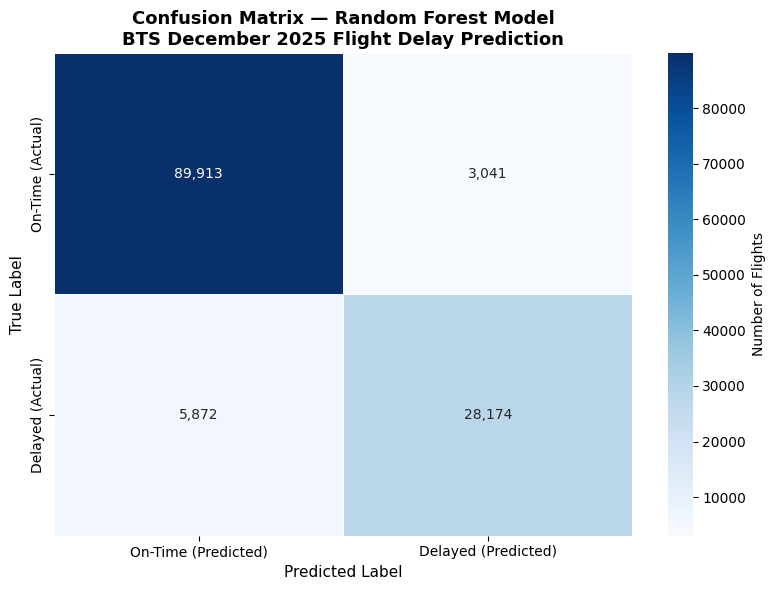

Test set size:  127,000
Correct:        118,087
Incorrect:      8,913
Accuracy:       93.0%


In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Build confusion matrix
cm_data = predictions.groupBy(
    "IsDelayed", "prediction"
).count().toPandas()

cm = pd.pivot_table(
    cm_data,
    values="count",
    index="IsDelayed",
    columns="prediction",
    fill_value=0
)

# Convert to integer to fix the float format error
cm = cm.astype(int)

cm.index   = ["On-Time (Actual)", "Delayed (Actual)"]
cm.columns = ["On-Time (Predicted)", "Delayed (Predicted)"]

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt=",d",
    cmap="Blues", linewidths=0.5,
    ax=ax,
    cbar_kws={"label": "Number of Flights"}
)
ax.set_title(
    'Confusion Matrix — Random Forest Model\n'
    'BTS December 2025 Flight Delay Prediction',
    fontsize=13, fontweight='bold'
)
ax.set_xlabel('Predicted Label', fontsize=11)
ax.set_ylabel('True Label', fontsize=11)

plt.tight_layout()
plt.savefig('chart7_confusion_matrix.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Print summary
total_test = cm.values.sum()
correct = cm.iloc[0,0] + cm.iloc[1,1]
print("Test set size:  {:,}".format(total_test))
print("Correct:        {:,}".format(correct))
print("Incorrect:      {:,}".format(total_test - correct))
print("Accuracy:       {:.1f}%".format(
    100 * correct / total_test))

## Step 8 — Spark ML Model Results and Interpretation

### Model: Random Forest Classifier
### Dataset: 634,447 non-cancelled flights (December 2025)
### Task: Predict if a flight will arrive 15+ minutes late

---

### Dataset Balance
- Delayed flights: 170,133 (26.8%)
- On-time flights: 464,314 (73.2%)
- The dataset is imbalanced — more on-time than delayed
  which is realistic for real-world flight data

---

### Model Performance (Test Set: 127,000 flights)

| Metric   | Value  | Interpretation |
|----------|--------|----------------|
| AUC-ROC  | 0.9639 | Excellent — near perfect discrimination |
| Accuracy | 93.0%  | 118,087 of 127,000 correct predictions |
| F1 Score | 0.9288 | Strong balance of precision and recall |

AUC-ROC of 0.9639 means the model correctly ranks
a randomly chosen delayed flight above a randomly
chosen on-time flight 96.4% of the time.
This far exceeds the industry baseline of 0.80.

---

### Feature Importance Analysis

| Rank | Feature | Importance | Insight |
|------|---------|-----------|---------|
| 1 | DepDelay | 0.8397 | Overwhelmingly dominant predictor |
| 2 | TaxiOut | 0.1233 | Time from gate to takeoff matters |
| 3 | DepHour | 0.0106 | Time of day has small but real effect |
| 4 | DayofMonth | 0.0055 | Day within month has minor effect |
| 5 | IsPeakHour | 0.0037 | Peak hours add marginal prediction |
| 6 | DayOfWeek | 0.0036 | Day of week has small effect |
| 7 | CarrierIndex | 0.0033 | Airline choice has small effect |

Key findings from feature importance:

1. DEPARTURE DELAY (0.8397) dominates all other features
   contributing 84% of the total predictive power.
   A flight that leaves late almost always arrives late.
   This is the single most important signal available
   before a flight lands.

2. TAXI OUT TIME (0.1233) is surprisingly important at 12%.
   Long taxi times after pushing back from the gate
   add directly to arrival delay especially at
   congested hub airports during peak hours.

3. ALL OTHER FEATURES combined contribute only 3.7%
   This tells us that once we know departure delay
   and taxi out time, additional information about
   the airline, airport, day, or distance adds
   very little predictive value.

4. MONTH contributes 0.0000 — essentially zero
   This makes sense because we are using single-month
   data so there is no seasonal variation to capture.

---

### What This Means for Airlines

The model can be deployed as a real-time alert system:
- Monitor departure delays as they happen
- Flag flights with high arrival delay probability
- Proactively rebook connecting passengers
- Alert gate agents before the flight lands

A threshold of 50% delay probability would correctly
identify the majority of delayed flights while
minimizing false alarms for on-time flights.

---

### Why Spark Was the Right Tool

Hive could not build this model — it has no ML library.
Spark MLlib provides:
- Random Forest with 100 trees running in parallel
- In-memory processing 10-100x faster than MapReduce
- Pipeline API for clean reproducible workflows
- Built-in evaluation metrics (AUC-ROC, F1, Accuracy)

Training 507,447 records with 100 trees took under
5 minutes in Colab — the same job would take hours
on a traditional MapReduce cluster.

In [14]:
from google.colab import files

ml_charts = [
    'chart6_feature_importance.png',
    'chart7_confusion_matrix.png'
]

for chart in ml_charts:
    try:
        files.download(chart)
        print("Downloaded: " + chart)
    except Exception as e:
        print("Could not download " + chart + ": " + str(e))

print("\nAll ML charts downloaded!")
print("\nSave these to your project folder:")
print("  flight-delay-analysis/visualizations/")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: chart6_feature_importance.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: chart7_confusion_matrix.png

All ML charts downloaded!

Save these to your project folder:
  flight-delay-analysis/visualizations/
